Actual:  [1 1 2 1 1 1 1 2 2 2 1 2 2 2 2 1 2 2 1 0 0 0 2 0 1 2 0 0 1 0 0 0 2 2 1 2 1
 1]
Predicted:  [1 1 2 1 1 1 1 2 2 2 1 2 2 2 0 1 2 2 1 0 0 0 2 0 1 2 0 0 1 0 0 0 0 2 1 2 1
 1]


True Pos:  9
True Neg:  0
False Pos:  0
False Neg:  14

Accuracy -  100.0 %
              precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       1.00      1.00      1.00        14
           2       1.00      0.87      0.93        15

    accuracy                           0.95        38
   macro avg       0.94      0.96      0.94        38
weighted avg       0.96      0.95      0.95        38



[Text(0.3333333333333333, 0.9285714285714286, 'x[3] <= -0.6\nentropy = 1.581\nsamples = 112\nvalue = [41, 36, 35]'),
 Text(0.2222222222222222, 0.7857142857142857, 'entropy = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.2777777777777778, 0.8571428571428572, 'True  '),
 Text(0.4444444444444444, 0.7857142857142857, 'x[3] <= 0.586\nentropy = 0.995\nsamples = 76\nvalue = [41, 0, 35]'),
 Text(0.38888888888888884, 0.8571428571428572, '  False'),
 Text(0.2222222222222222, 0.6428571428571429, 'x[2] <= 0.902\nentropy = 0.169\nsamples = 40\nvalue = [39, 0, 1]'),
 Text(0.1111111111111111, 0.5, 'entropy = 0.0\nsamples = 39\nvalue = [39, 0, 0]'),
 Text(0.3333333333333333, 0.5, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6666666666666666, 0.6428571428571429, 'x[2] <= 0.73\nentropy = 0.31\nsamples = 36\nvalue = [2, 0, 34]'),
 Text(0.5555555555555556, 0.5, 'x[1] <= -0.339\nentropy = 0.811\nsamples = 8\nvalue = [2, 0, 6]'),
 Text(0.4444444444444444, 0.35714285714285715, 'entropy = 0.0\

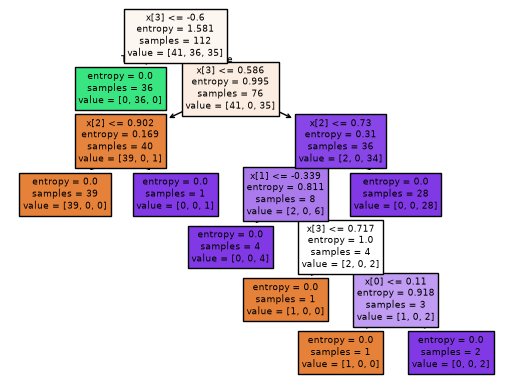

In [20]:
# for below cells parameters are:
#     1. entropy
#     2. 0.25

# # dataset = "Iris Dataset"

import pandas as ps
import numpy as nm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

df = ps.read_csv("D:\BDA 20\AIML-BDA-Lab-Work\data\Iris.csv")
df.head()


x = df.iloc[:, 1:5].values      # SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm

y = df.iloc[:, -1].values        # Species


x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    test_size=0.25,
    random_state=45
)

sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train) 
x_test=sc_x.transform(x_test)

classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)

classifier.fit(x_train,y_train)


y_pred = classifier.predict(x_test)       
print("Actual: ",y_test)
print("Predicted: ",y_pred)


cm = confusion_matrix(y_test, y_pred)

print("\n\nTrue Pos: ", cm[0][0])
print("True Neg: ", cm[0][1])
print("False Pos: ", cm[1][0])
print("False Neg: ", cm[1][1])

accuracy = (cm[0][0]  + cm[1][1]) / (cm[0][0]  + cm[1][1] + cm[1][0] + cm[0][1])
print("\nAccuracy - ", accuracy * 100, "%")


print(classification_report(y_test, y_pred))

from sklearn import tree
tree.plot_tree(classifier, filled=True)

In [21]:
import pandas as ps
import numpy as nm
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.pipeline import make_pipeline
# --------------------------
# Load and prepare data
# --------------------------
df = ps.read_csv("D:\\BDA 20\\AIML-BDA-Lab-Work\\data\\Iris.csv")
df.head()

x = df.iloc[:, 1:5].values      # SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm
y = df.iloc[:, -1].values       # Species


# --------------------------
# K-Fold Cross-Validation (on full dataset, using a pipeline to avoid leakage)
# --------------------------

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(criterion='entropy', random_state=0)
)

scores = cross_val_score(pipeline, x, y, cv=kfold, scoring='accuracy')
print("\n--- K-Fold Cross-Validation Results ---")
print("Accuracy for each fold:", scores)
print("Mean Accuracy:", scores.mean() * 100, "%")
print("Std Deviation:", scores.std())

# Predictions across all folds (for an overall CV confusion matrix / report)
y_pred_cv = cross_val_predict(pipeline, x, y, cv=kfold)

cm_cv = confusion_matrix(y, y_pred_cv)
print("\nConfusion Matrix (K-Fold):\n", cm_cv)

print("\nClassification Report (K-Fold):\n", classification_report(y, y_pred_cv))
print("Overall K-Fold Accuracy:", accuracy_score(y, y_pred_cv) * 100, "%")


--- K-Fold Cross-Validation Results ---
Accuracy for each fold: [1.         0.96666667 0.93333333 0.96666667 0.9       ]
Mean Accuracy: 95.33333333333334 %
Std Deviation: 0.03399346342395189

Confusion Matrix (K-Fold):
 [[47  0  3]
 [ 0 50  0]
 [ 4  0 46]]

Classification Report (K-Fold):
               precision    recall  f1-score   support

           0       0.92      0.94      0.93        50
           1       1.00      1.00      1.00        50
           2       0.94      0.92      0.93        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

Overall K-Fold Accuracy: 95.33333333333334 %
